<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab05/lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embeddings w praktyce -- cwiczenia laboratoryjne

W tym notatniku przeczwiczymy:

1. Korzystanie z pretrenowanych embeddingów (Gensim, spaCy)
2. Podobieństwo słów i wyszukiwanie najbliższych sąsiadów
3. Analogie wektorowe (arytmetyka na słowach)
4. Wizualizację embeddingów za pomocą t-SNE
5. Trenowanie własnego modelu Word2Vec
6. Porównanie modeli Skip-gram i CBOW

---
## 0. Instalacja i import bibliotek

Google Colab wymaga doinstalowania `gensim` i `datasets`. Modele spaCy pobieramy osobno.

In [10]:
!pip install gensim datasets -q
!python -m spacy download en_core_web_md -q
!python -m spacy download pl_core_news_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 26.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 MB 14.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import gensim.downloader as api
from gensim.models import Word2Vec, KeyedVectors
from gensim.utils import simple_preprocess
import spacy

print("Wszystko gotowe!")

Wszystko gotowe!


---
## 1. Przyklad z omowieniem -- pretrenowane embeddingi GloVe

Pobieramy model GloVe wytrenowany na korpusie Wikipedia 2014 + Gigaword 5 (100 wymiarow).
Kazde slowo jest reprezentowane jako wektor 100 liczb zmiennoprzecinkowych.

In [12]:
model = api.load("glove-wiki-gigaword-100")

# Rozmiar slownika i wymiar
print(f"Slownik: {len(model)} slow")
print(f"Wymiar wektora: {model.vector_size}")

# Wektor dla slowa
vec = model['python']
print(f"Ksztalt: {vec.shape}")
print(f"Pierwsze 10 wartosci: {vec[:10]}")

Slownik: 400000 slow
Wymiar wektora: 100
Ksztalt: (100,)
Pierwsze 10 wartosci: [ 0.24934    0.68318   -0.044711  -1.3842    -0.0073079  0.651
 -0.33958   -0.19785   -0.33925    0.26691  ]


### Interpretacja

Wektor `model['python']` to tablica NumPy o ksztalcie `(100,)`. Te 100 wartosci to wspolrzedne slowa w przestrzeni semantycznej. Pojedyncza liczba nie ma czytelnej interpretacji, ale lacznie koduja znaczenie -- slowa o podobnym sensie maja podobne wektory.

### 1.1 Podobienstwo slow

Sprawdzamy podobienstwo cosinusowe miedzy slowami, wyszukujemy najblizszych sasiadow i slowa "nie pasujace" do grupy.

In [13]:
# Najbardziej podobne slowa
similar = model.most_similar("king", topn=10)
print("Najbardziej podobne do 'king':")
for word, score in similar:
    print(f"  {word:15s} {score:.4f}")

# Podobienstwo miedzy dwoma slowami
sim = model.similarity("cat", "dog")
print(f"\nPodobienstwo cat-dog: {sim:.4f}")

sim2 = model.similarity("cat", "car")
print(f"Podobienstwo cat-car: {sim2:.4f}")

# Ktory nie pasuje?
outlier = model.doesnt_match(["cat", "dog", "fish", "computer"])
print(f"\nNie pasuje: {outlier}")

Najbardziej podobne do 'king':
  prince          0.7682
  queen           0.7508
  son             0.7021
  brother         0.6986
  monarch         0.6978
  throne          0.6920
  kingdom         0.6811
  father          0.6802
  emperor         0.6713
  ii              0.6676

Podobienstwo cat-dog: 0.8798
Podobienstwo cat-car: 0.3110

Nie pasuje: computer


### Interpretacja

- **`cat` vs `dog`** -- wysokie podobienstwo, bo oba to zwierzeta domowe czesto wystepujace w podobnych kontekstach.
- **`cat` vs `car`** -- niskie podobienstwo, bo te slowa pojawiaja sie w zupelnie roznych kontekstach.
- **`doesnt_match`** -- `computer` jest najdalszy od pozostalych, bo nie jest zwierzeciem.

### 1.2 Analogie wektorowe

Najbardziej znana wlasciwosc embeddingów -- **arytmetyka na wektorach**:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

In [14]:
# king - man + woman = ?
result = model.most_similar(
    positive=["king", "woman"],
    negative=["man"],
    topn=5
)
print("king - man + woman =")
for word, score in result:
    print(f"  {word:15s} {score:.4f}")

# Inne analogie
analogies = [
    (["paris", "poland"], ["france"], "stolice"),
    (["bigger", "small"], ["big"], "stopniowanie"),
    (["walking", "swam"], ["walked"], "czas gramatyczny"),
]
for pos, neg, label in analogies:
    res = model.most_similar(positive=pos, negative=neg, topn=1)
    print(f"\n{label}: {res[0][0]} ({res[0][1]:.4f})")

king - man + woman =
  queen           0.7699
  monarch         0.6843
  throne          0.6756
  daughter        0.6595
  princess        0.6521

stolice: warsaw (0.8550)

stopniowanie: larger (0.8925)

czas gramatyczny: swimming (0.7068)


### Interpretacja analogii

Metoda `most_similar` przyjmuje wektory z listy `positive`, odejmuje wektory z `negative` i zwraca slowa najblizsze wynikowi:

- **king - man + woman ≈ queen** -- relacja plci zakodowana jako kierunek w przestrzeni wektorowej
- **paris - france + poland ≈ warsaw** -- relacja stolica-kraj
- **bigger - big + small ≈ smaller** -- relacja stopniowania

### 1.3 Wizualizacja embeddingów -- t-SNE

Redukcja wymiarowosci za pomoca t-SNE pozwala zobaczyc, jak embeddingi grupuja slowa z tych samych kategorii semantycznych.

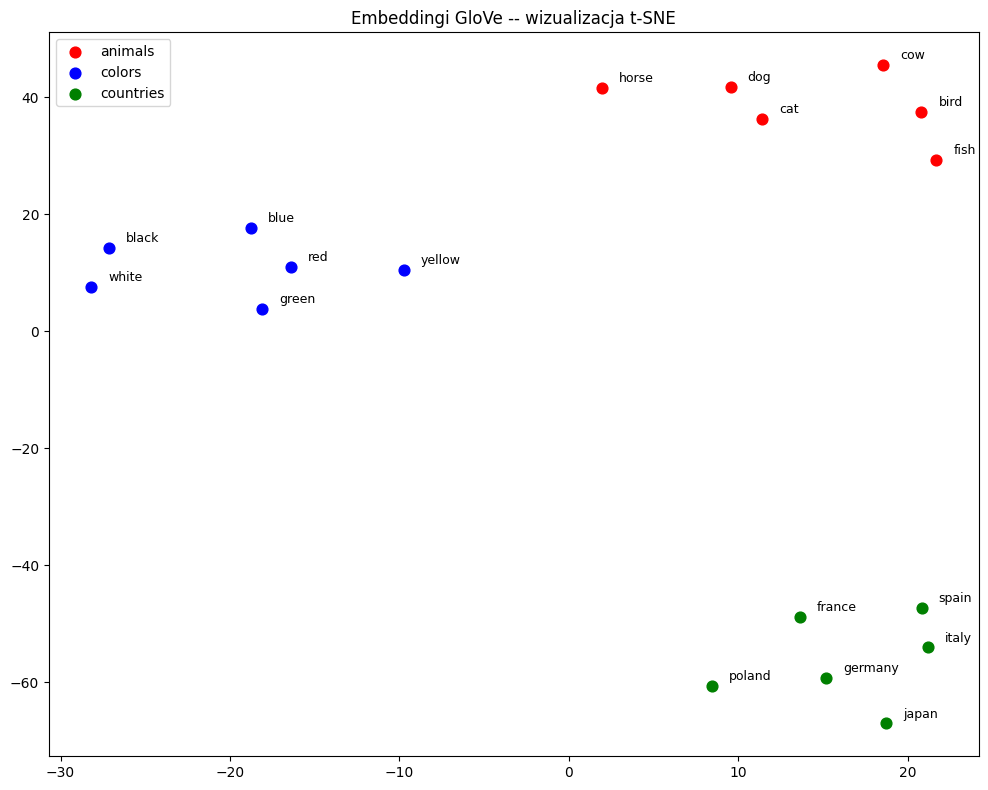

In [15]:
groups = {
    "animals": ["cat", "dog", "fish", "bird", "horse", "cow"],
    "colors": ["red", "blue", "green", "yellow", "black", "white"],
    "countries": ["france", "germany", "poland", "italy", "spain", "japan"],
}

words, vectors, labels = [], [], []
for label, group in groups.items():
    for w in group:
        words.append(w)
        vectors.append(model[w])
        labels.append(label)

# t-SNE redukcja do 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(np.array(vectors))

# Rysowanie
fig, ax = plt.subplots(figsize=(10, 8))
colors_map = {"animals": "red", "colors": "blue", "countries": "green"}
plotted_labels = set()

for i, w in enumerate(words):
    group = labels[i]
    ax.scatter(coords[i, 0], coords[i, 1],
               c=colors_map[group], s=60,
               label=group if group not in plotted_labels else "")
    plotted_labels.add(group)
    ax.annotate(w, (coords[i, 0]+1, coords[i, 1]+1), fontsize=9)

ax.legend()
ax.set_title("Embeddingi GloVe -- wizualizacja t-SNE")
plt.tight_layout()
plt.show()

### Interpretacja wizualizacji

Na wykresie t-SNE widzimy, ze slowa z tych samych kategorii semantycznych tworza skupiska blisko siebie:
- **Zwierzeta** (czerwone) -- zgrupowane razem
- **Kolory** (niebieskie) -- tworzą oddzielny klaster
- **Kraje** (zielone) -- oddzielona grupa

To potwierdza, ze embeddingi koduja znaczenie: slowa semantycznie pokrewne maja bliskie wektory.

### 1.4 Embeddingi w spaCy

spaCy integruje embeddingi bezposrednio w pipeline NLP. Model `md` zawiera wstepnie wytrenowane wektory slow (300-wymiarowe).

In [16]:
nlp = spacy.load("en_core_web_md")

# Wektor pojedynczego tokena
token = nlp("cat")[0]
print(f"Wektor 'cat': wymiar {token.vector.shape}")
print(f"Czy ma wektor: {token.has_vector}")

# Podobienstwo miedzy dokumentami
doc1 = nlp("I like dogs")
doc2 = nlp("I enjoy cats")
doc3 = nlp("The stock market crashed")
print(f"\ndogs vs cats: {doc1.similarity(doc2):.3f}")
print(f"dogs vs stock: {doc1.similarity(doc3):.3f}")

Wektor 'cat': wymiar (300,)
Czy ma wektor: True

dogs vs cats: 0.794
dogs vs stock: 0.310


### Interpretacja spaCy

- Wektor dokumentu w spaCy to **srednia arytmetyczna** wektorow wszystkich tokenow.
- `"I like dogs"` vs `"I enjoy cats"` -- wysokie podobienstwo (ten sam temat, inne slowa).
- `"I like dogs"` vs `"The stock market crashed"` -- niskie podobienstwo (zupelnie inne tematy).

To kluczowa wlasciwosc embeddingów: mierza **bliskosc znaczeniowa**, nie doslowne pokrywanie sie slow.

### 1.5 Trenowanie wlasnego modelu Word2Vec

Na malym korpusie trenujemy model Skip-gram, zeby zobaczyc caly proces od tokenizacji do analizy wynikow.

In [17]:
# Przykladowy korpus
corpus_text = """
Uczenie maszynowe to dziedzina sztucznej inteligencji.
Sieci neuronowe sa fundamentem glebokiego uczenia.
Przetwarzanie jezyka naturalnego wykorzystuje modele jezykowe.
Word embeddings reprezentuja slowa jako wektory liczbowe.
Klasyfikacja tekstu to jedno z podstawowych zadan NLP.
Analiza sentymentu pozwala okreslic wydzwiek opinii.
Transformery zrewolucjonizowaly przetwarzanie jezyka naturalnego.
Tokenizacja to pierwszy krok w przetwarzaniu tekstu.
Modele jezykowe przewiduja nastepne slowo w sekwencji.
Korpus to zbior tekstow uzywany do trenowania modeli.
"""

# Tokenizacja
sentences = [
    simple_preprocess(line)
    for line in corpus_text.strip().split("\n")
    if line.strip()
]

print(f"Liczba zdan: {len(sentences)}")
for s in sentences[:3]:
    print(s)

Liczba zdan: 10
['uczenie', 'maszynowe', 'to', 'dziedzina', 'sztucznej', 'inteligencji']
['sieci', 'neuronowe', 'sa', 'fundamentem', 'glebokiego', 'uczenia']
['przetwarzanie', 'jezyka', 'naturalnego', 'wykorzystuje', 'modele', 'jezykowe']


In [18]:
# Trening modelu Skip-gram
model_sg = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,
    negative=5,
    epochs=100,
    seed=42,
)

print(f"Slownik: {len(model_sg.wv)} slow")
print(f"Wymiar: {model_sg.wv.vector_size}")

# Najblizsze slowa
print("\nNajblizsze do 'jezyka':")
for word, score in model_sg.wv.most_similar("jezyka", topn=5):
    print(f"  {word:20s} {score:.4f}")

Slownik: 53 slow
Wymiar: 50

Najblizsze do 'jezyka':
  wykorzystuje         0.3156
  przetwarzaniu        0.2962
  neuronowe            0.2680
  przetwarzanie        0.2587
  slowa                0.2176


### Interpretacja trenowania

Model wytrenowany na malym korpusie (10 zdan) daje ograniczone wyniki -- nie ma wystarczajaco duzo kontekstow, zeby dobrze nauczyc sie relacji semantycznych. Dlatego w praktyce:
- Uzywamy **pretrenowanych modeli** (GloVe, FastText) lub
- Trenujemy na **duzych korpusach** (np. fragment Wikipedii -- tysiac+ artykulow)

Parametry `vector_size`, `window`, `min_count`, `sg` wplywaja na jakosc wynikow.

---
---
## 2. Zadanie do samodzielnej realizacji -- A

### Eksploracja pretrenowanych embeddingów -- podobienstwo i analogie

Zaladuj pretrenowany model GloVe (`glove-wiki-gigaword-100`) i wykonaj ponizsze kroki.

**Wykonaj ponizsze kroki:**

1. Wyswietl **wektor** dla slowa `"university"` -- jego ksztalt i pierwsze 10 wartosci.
2. Znajdz **10 najblizszych sasiadow** dla slow: `"science"`, `"music"`, `"football"`. Czy wyniki sa sensowne?
3. Oblicz **podobienstwo cosinusowe** miedzy parami: (`"doctor"`, `"nurse"`), (`"doctor"`, `"airplane"`), (`"happy"`, `"sad"`), (`"happy"`, `"joyful"`). Ktore pary sa najblizsze?
4. Uzyj metody `doesnt_match` dla grup: `["apple", "banana", "orange", "car"]` oraz `["dog", "cat", "mouse", "table"]`.
5. Sprawdz **analogie wektorowe**: `japan - tokyo + paris = ?`, `teacher - school + hospital = ?`, `slow - slower + faster = ?`.
6. Stworz **wizualizacje t-SNE** dla 4 grup slow (po 5 slow kazda): sporty, zawody, jedzenie, emocje.

In [19]:
model = api.load("glove-wiki-gigaword-100")

In [20]:
# Krok 1: Wektor slowa "university"
# vec = model['university']
# Wyswietl: ksztalt i pierwsze 10 wartosci



In [21]:
# Krok 2: 10 najblizszych sasiadow dla "science", "music", "football"
# Wskazowka: model.most_similar(slowo, topn=10)



In [22]:
# Krok 3: Podobienstwo cosinusowe miedzy parami
# Wskazowka: model.similarity(slowo1, slowo2)
# Pary: ("doctor","nurse"), ("doctor","airplane"), ("happy","sad"), ("happy","joyful")



In [23]:
# Krok 4: doesnt_match
# Wskazowka: model.doesnt_match([...])
# Grupy: ["apple","banana","orange","car"] oraz ["dog","cat","mouse","table"]



In [24]:
# Krok 5: Analogie wektorowe
# Wskazowka: model.most_similar(positive=[...], negative=[...], topn=1)
# japan - tokyo + paris = ?
# teacher - school + hospital = ?
# slow - slower + faster = ?



In [25]:
# Krok 6: Wizualizacja t-SNE dla 4 grup slow
# Grupy: sporty (np. football, tennis, basketball, swimming, volleyball)
#         zawody (np. doctor, teacher, engineer, lawyer, nurse)
#         jedzenie (np. pizza, pasta, bread, cheese, rice)
#         emocje (np. happy, sad, angry, scared, surprised)
# Wskazowka: uzyj kodu z przykladu, dodaj 4. grupe i 4. kolor



---
---
## 3. Zadanie do samodzielnej realizacji -- B

### Polskie embeddingi -- spaCy i porownanie dokumentow

Zaladuj polski model spaCy (`pl_core_news_md`) i przeanalizuj podany korpus polskich zdan.

**Wykonaj ponizsze kroki:**

1. Oblicz **podobienstwo** miedzy wszystkimi parami zdan z korpusu (cosine similarity). Wyswietl wyniki jako macierz.
2. Dla kazdego zdania znajdz **najblizsze** i **najdalsze** zdanie z korpusu.
3. Napisz funkcje `znajdz_najblizsze(query, zdania, nlp, n=3)`, ktora przyjmuje nowe zdanie i zwraca `n` najblizszych zdan z korpusu.
4. Przetestuj funkcje na zapytaniach: `"Jaki jest kurs dolara?"`, `"Chce kupic nowy komputer"`, `"Najlepsze restauracje w Krakowie"`.
5. Zbadaj, czy slowa wieloznaczne (np. `"zamek"`, `"klucz"`, `"pilot"`) maja sensowne wektory -- sprawdz ich najblizszych sasiadow w slowniki spaCy.
6. Stworz **wizualizacje t-SNE** wektorow zdan z korpusu, kolorujac je wg kategorii.

In [26]:
nlp_pl = spacy.load("pl_core_news_md")

zdania = [
    # FINANSE (0-3)
    "Kurs euro wzrosl do najwyzszego poziomu od poczatku roku",
    "Gielda warszawska zamknela sesje na plusie po dobrych wynikach spolek",
    "Inflacja spadla do najnizszego poziomu od dwoch lat",
    "Bank centralny podjal decyzje o obnizeniu stop procentowych",

    # TECHNOLOGIA (4-7)
    "Premiera nowego systemu operacyjnego przyciagnela miliony uzytkownikow",
    "Sztuczna inteligencja zmienia sposob tworzenia oprogramowania",
    "Firma technologiczna zaprezentowala innowacyjny chip do smartfonow",
    "Cyberbezpieczenstwo staje sie priorytetem dla polskich przedsiebiorstw",

    # TURYSTYKA (8-11)
    "Sezon turystyczny w Zakopanem zapowiada sie rekordowo",
    "Nowe polaczenia lotnicze z Polski do Azji Poludniowo-Wschodniej",
    "Krakow znalazl sie w czolowce najpopularniejszych miast do odwiedzenia",
    "Polskie wybrzeze przyciaga coraz wiecej turystow z zagranicy",
]

kategorie_zdan = ["Finanse"]*4 + ["Technologia"]*4 + ["Turystyka"]*4

print(f"Korpus: {len(zdania)} zdan")
for i, z in enumerate(zdania):
    print(f"  D{i:2d} [{kategorie_zdan[i]:>12s}]: {z}")

Korpus: 12 zdan
  D 0 [     Finanse]: Kurs euro wzrosl do najwyzszego poziomu od poczatku roku
  D 1 [     Finanse]: Gielda warszawska zamknela sesje na plusie po dobrych wynikach spolek
  D 2 [     Finanse]: Inflacja spadla do najnizszego poziomu od dwoch lat
  D 3 [     Finanse]: Bank centralny podjal decyzje o obnizeniu stop procentowych
  D 4 [ Technologia]: Premiera nowego systemu operacyjnego przyciagnela miliony uzytkownikow
  D 5 [ Technologia]: Sztuczna inteligencja zmienia sposob tworzenia oprogramowania
  D 6 [ Technologia]: Firma technologiczna zaprezentowala innowacyjny chip do smartfonow
  D 7 [ Technologia]: Cyberbezpieczenstwo staje sie priorytetem dla polskich przedsiebiorstw
  D 8 [   Turystyka]: Sezon turystyczny w Zakopanem zapowiada sie rekordowo
  D 9 [   Turystyka]: Nowe polaczenia lotnicze z Polski do Azji Poludniowo-Wschodniej
  D10 [   Turystyka]: Krakow znalazl sie w czolowce najpopularniejszych miast do odwiedzenia
  D11 [   Turystyka]: Polskie wybrzeze przy

In [27]:
# Krok 1: Macierz podobienstwa miedzy zdaniami
# Wskazowka: nlp_pl(zdanie).vector daje wektor zdania
# Uzyj cosine_similarity ze sklearn lub oblicz recznie
from sklearn.metrics.pairwise import cosine_similarity



In [28]:
# Krok 2: Dla kazdego zdania -- najblizsze i najdalsze
# Wskazowka: z macierzy podobienstwa, ignoruj diagonale (podobienstwo do siebie)



In [29]:
# Krok 3: Funkcja znajdz_najblizsze(query, zdania, nlp, n=3)
# Wskazowka:
# def znajdz_najblizsze(query, zdania, nlp, n=3):
#     q_vec = nlp(query).vector.reshape(1, -1)
#     z_vecs = np.array([nlp(z).vector for z in zdania])
#     sim = cosine_similarity(q_vec, z_vecs).flatten()
#     ...



In [30]:
# Krok 4: Testy funkcji
# znajdz_najblizsze("Jaki jest kurs dolara?", zdania, nlp_pl)
# znajdz_najblizsze("Chce kupic nowy komputer", zdania, nlp_pl)
# znajdz_najblizsze("Najlepsze restauracje w Krakowie", zdania, nlp_pl)



In [31]:
# Krok 5: Slowa wieloznaczne -- najblizsi sasiedzi
# Wskazowka: uzyj nlp_pl.vocab i oblicz cosine similarity
# Sprawdz slowa: "zamek", "klucz", "pilot"



In [32]:
# Krok 6: Wizualizacja t-SNE wektorow zdan
# Wskazowka: oblicz wektory zdan, uzyj TSNE, koloruj wg kategorii



---
---
## 4. Zadanie do samodzielnej realizacji -- C

### Trenowanie Word2Vec na wiekszym korpusie i porownanie modeli

Pobierz fragment polskiej Wikipedii z Hugging Face i wytrenuj wlasne modele Word2Vec.

**Wykonaj ponizsze kroki:**

1. Pobierz **1000 artykulow** z polskiej Wikipedii (`wikimedia/wikipedia`, `20231101.pl`). Przygotuj zdania za pomoca `simple_preprocess`.
2. Wytrenuj model **Skip-gram** (`sg=1`, `vector_size=100`, `window=5`, `min_count=5`, `epochs=10`).
3. Wytrenuj model **CBOW** (`sg=0`) z tymi samymi parametrami.
4. **Porownaj oba modele** -- dla slow `"polska"`, `"warszawa"`, `"nauka"` wyswietl 5 najblizszych sasiadow z kazdego modelu.
5. Sprawdz **analogie** w wytrenowanym modelu: `polska - warszawa + berlin = ?`, `krol - mezczyzna + kobieta = ?`.
6. **Zapisz** model Skip-gram do pliku i wczytaj go ponownie. Sprawdz, czy wyniki sa identyczne.
7. Zbadaj wplyw parametru `window` -- wytrenuj 3 modele z `window=2`, `window=5`, `window=10` i porownaj wyniki dla slowa `"historia"`.

In [33]:
from datasets import load_dataset

# Krok 1: Pobranie i preprocessing polskiej Wikipedii
# ds = load_dataset("wikimedia/wikipedia", "20231101.pl", split="train[:1000]")
# sentences_pl = []
# for article in ds:
#     text = article["text"]
#     for line in text.split("\n"):
#         tokens = simple_preprocess(line, deacc=False)
#         if len(tokens) >= 3:
#             sentences_pl.append(tokens)
# print(f"Liczba zdan: {len(sentences_pl)}")



In [34]:
# Krok 2: Trening Skip-gram
# model_sg = Word2Vec(
#     sentences=sentences_pl,
#     vector_size=100, window=5, min_count=5,
#     sg=1, negative=10, epochs=10, workers=4, seed=42
# )



In [35]:
# Krok 3: Trening CBOW
# model_cbow = Word2Vec(
#     sentences=sentences_pl,
#     vector_size=100, window=5, min_count=5,
#     sg=0, negative=10, epochs=10, workers=4, seed=42
# )



In [36]:
# Krok 4: Porownanie Skip-gram vs CBOW
# Dla slow: "polska", "warszawa", "nauka"
# Wyswietl 5 najblizszych sasiadow z kazdego modelu



In [37]:
# Krok 5: Analogie w wytrenowanym modelu
# polska - warszawa + berlin = ?
# krol - mezczyzna + kobieta = ?
# Wskazowka: model_sg.wv.most_similar(positive=[...], negative=[...])



In [38]:
# Krok 6: Zapis i wczytanie modelu
# model_sg.save("word2vec_sg.model")
# model_loaded = Word2Vec.load("word2vec_sg.model")
# Sprawdz czy wyniki sa identyczne



In [39]:
# Krok 7: Wplyw parametru window
# Wytrenuj 3 modele z window=2, 5, 10
# Porownaj najblizszych sasiadow slowa "historia"

